# Perbandingan Preprocessing terhadap Performa Klasifikasi

Notebook ini menguji seberapa besar pengaruh dua langkah preprocessing - **penghapusan tanda baca** dan **penghapusan kata fungsi (stopword)** - terhadap performa klasifikasi Naive Bayes, dengan membandingkan 3 kondisi:

| Kondisi | Tanda Baca | Stopword | Keterangan |
|---|---|---|---|
| **A. Lengkap** | Dihapus | Dihapus | Preprocessing penuh (baseline) |
| **B. Tanpa Stopword Removal** | Dihapus | **Dipertahankan** | Menguji efek stopword saja |
| **C. Tanpa Hapus Tanda Baca** | **Dipertahankan** | Dihapus | Menguji efek tanda baca saja |

Untuk menjaga eksperimen tetap terkendali (hanya 1 variabel berubah di tiap kondisi), ketiga kondisi dibangun dari teks mentah yang sama menggunakan pipeline pembersihan sederhana dan konsisten (case folding), bukan pipeline lengkap di `Preprocessing.ipynb` yang jauh lebih kompleks.

In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/dataset_berita_200.xlsx")
print("Dataset dimuat:", df.shape)

Dataset dimuat: (200, 4)


## 1. Bangun 3 Versi Teks (Kondisi A, B, C)

In [9]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

def kondisi_a_lengkap(teks):
    teks = teks.lower()
    teks = re.sub(r"[^a-z\s]", " ", teks)           # hapus tanda baca & angka
    teks = re.sub(r"\s+", " ", teks).strip()
    teks = stopword_remover.remove(teks)            # hapus stopword
    return teks

def kondisi_b_tanpa_stopword(teks):
    teks = teks.lower()
    teks = re.sub(r"[^a-z\s]", " ", teks)           # hapus tanda baca & angka
    teks = re.sub(r"\s+", " ", teks).strip()
    return teks                                     # stopword TIDAK dihapus

def kondisi_c_tanpa_hapus_tanda_baca(teks):
    teks = teks.lower()                             # tanda baca DIPERTAHANKAN
    teks = re.sub(r"\s+", " ", teks).strip()
    teks = stopword_remover.remove(teks)            # stopword tetap dihapus
    return teks

df["kondisi_a"] = df["isi_berita"].apply(kondisi_a_lengkap)
df["kondisi_b"] = df["isi_berita"].apply(kondisi_b_tanpa_stopword)
df["kondisi_c"] = df["isi_berita"].apply(kondisi_c_tanpa_hapus_tanda_baca)

print("Selesai membangun 3 versi teks untuk 200 artikel.\n")
print("=== Contoh (100 karakter pertama, artikel id=1) ===")
print("A (lengkap)             :", df["kondisi_a"].iloc[0][:100])
print("B (tanpa stopword)      :", df["kondisi_b"].iloc[0][:100])
print("C (tanpa hapus tanda baca):", df["kondisi_c"].iloc[0][:100])

Selesai membangun 3 versi teks untuk 200 artikel.

=== Contoh (100 karakter pertama, artikel id=1) ===
A (lengkap)             : chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi nagoya jepang jelang asian
B (tanpa stopword)      : chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi di nagoya jepang jelang as
C (tanpa hapus tanda baca): chef de mission (cdm) indonesia todotua pasaribu terus memonitoring kondisi nagoya, jepang jelang as


## 2. Statistik Ukuran Vocabulary Tiap Kondisi

In [10]:
hasil_vocab = {}
for kondisi in ["kondisi_a", "kondisi_b", "kondisi_c"]:
    semua_token = " ".join(df[kondisi]).split()
    hasil_vocab[kondisi] = {
        "total_token": len(semua_token),
        "kata_unik": len(set(semua_token)),
    }

pd.DataFrame(hasil_vocab).T

,total_token,kata_unik
kondisi_a,51796,7419
kondisi_b,65425,7439
kondisi_c,54021,11918


## 3. TF-IDF + Naive Bayes untuk Tiap Kondisi

Untuk tiap kondisi, teks diubah menjadi TF-IDF, dataset dibagi menjadi data latih dan data uji (dengan pembagian yang **sama** di ketiga kondisi agar perbandingannya adil), lalu diklasifikasikan menggunakan **Multinomial Naive Bayes**.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pembagian data yang SAMA untuk ketiga kondisi (agar perbandingan adil)
indeks_latih, indeks_uji = train_test_split(
    df.index, test_size=0.2, stratify=df["label"], random_state=42
)

def evaluasi_kondisi(kolom_teks):
    vectorizer = TfidfVectorizer(min_df=2)
    X = vectorizer.fit_transform(df[kolom_teks])
    y = df["label"]

    X_latih, X_uji = X[indeks_latih], X[indeks_uji]
    y_latih, y_uji = y.loc[indeks_latih], y.loc[indeks_uji]

    model = MultinomialNB()
    model.fit(X_latih, y_latih)
    prediksi = model.predict(X_uji)

    akurasi = accuracy_score(y_uji, prediksi)
    return akurasi, y_uji, prediksi, X.shape[1]

hasil = {}
for kondisi, nama in [("kondisi_a", "A. Lengkap"), ("kondisi_b", "B. Tanpa Stopword"), ("kondisi_c", "C. Tanpa Hapus Tanda Baca")]:
    akurasi, y_uji, prediksi, jumlah_fitur = evaluasi_kondisi(kondisi)
    hasil[nama] = {"akurasi": akurasi, "jumlah_fitur_tfidf": jumlah_fitur, "y_uji": y_uji, "prediksi": prediksi}
    print(f"{nama:28} -> akurasi: {akurasi:.4f}  (jumlah fitur TF-IDF: {jumlah_fitur})")

A. Lengkap                   -> akurasi: 0.9750  (jumlah fitur TF-IDF: 3741)
B. Tanpa Stopword            -> akurasi: 0.9750  (jumlah fitur TF-IDF: 3770)
C. Tanpa Hapus Tanda Baca    -> akurasi: 0.9750  (jumlah fitur TF-IDF: 3919)


## 4. Bandingkan Hasil Secara Visual

In [12]:
ringkasan = pd.DataFrame({
    "Kondisi": list(hasil.keys()),
    "Akurasi": [v["akurasi"] for v in hasil.values()],
    "Jumlah Fitur TF-IDF": [v["jumlah_fitur_tfidf"] for v in hasil.values()],
})
ringkasan

,Kondisi,Akurasi,Jumlah Fitur TF-IDF
0,A. Lengkap,0.975,3741
1,B. Tanpa Stopword,0.975,3770
2,C. Tanpa Hapus Tanda Baca,0.975,3919


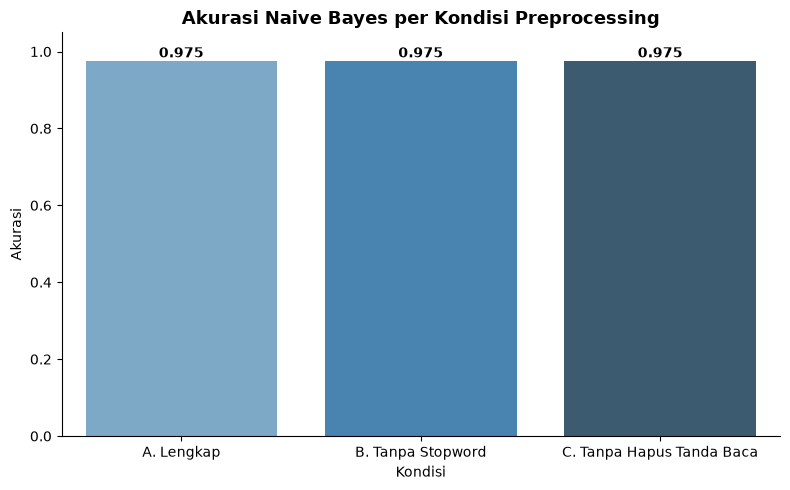

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ringkasan, x="Kondisi", y="Akurasi", hue="Kondisi", palette="Blues_d", legend=False, ax=ax)
for i, v in enumerate(ringkasan["Akurasi"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_title("Akurasi Naive Bayes per Kondisi Preprocessing", fontsize=13, fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Confusion Matrix Tiap Kondisi

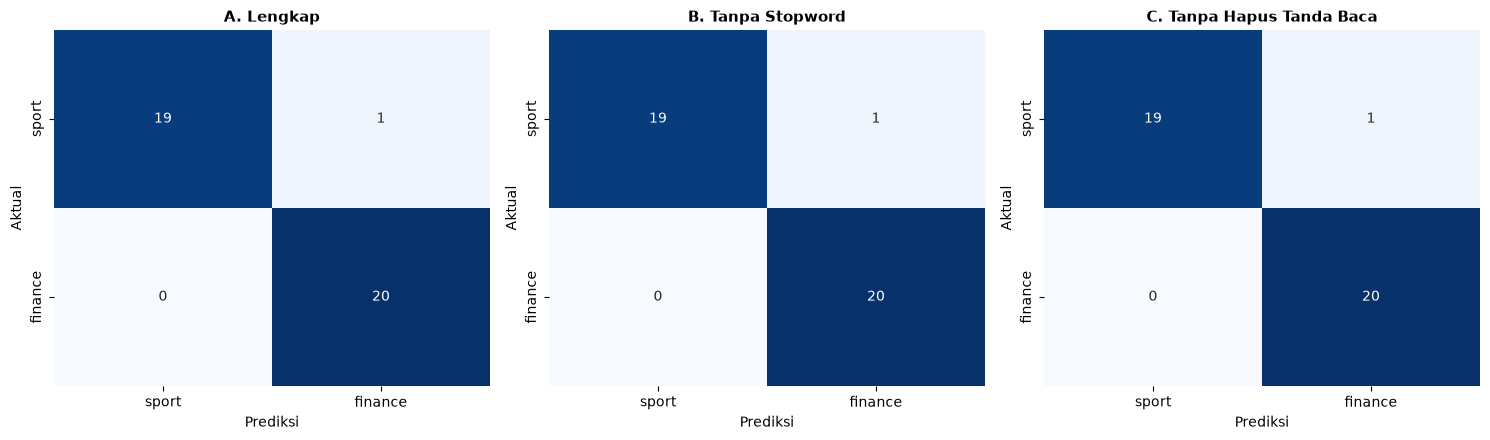

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nama, v) in zip(axes, hasil.items()):
    cm = confusion_matrix(v["y_uji"], v["prediksi"], labels=["sport", "finance"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["sport", "finance"], yticklabels=["sport", "finance"], cbar=False)
    ax.set_title(nama, fontsize=11, fontweight="bold")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.show()

## Ringkasan

- Ketiga kondisi diuji dengan pembagian data latih/uji yang identik, sehingga selisih akurasi yang muncul murni disebabkan oleh perbedaan langkah preprocessing, bukan faktor lain.
- **Menghapus tanda baca** umumnya berdampak pada jumlah fitur TF-IDF (karena tanpa pembersihan, kombinasi tanda baca dapat menciptakan token yang tidak konsisten), sementara **menghapus stopword** mengurangi jumlah fitur namun berfokus pada kata yang membawa makna topik.
- Perbandingan akurasi di atas menunjukkan bagaimana kedua langkah preprocessing tersebut secara empiris memengaruhi (atau tidak banyak memengaruhi) kemampuan model dalam membedakan artikel sport dan finance pada dataset ini.